### 1. Imports & Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### 2. Configuration

In [2]:
DATA_DIR = '/Users/rose/Documents/Projects/CNN Skin Disease/dataset'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

BATCH_SIZE    = 64       # larger batches = faster
NUM_EPOCHS    = 5        # enough to show learning trend
LEARNING_RATE = 0.001
NUM_CLASSES   = 23
IMG_SIZE      = 64       # smaller images = way faster (224→64 is huge speedup)

### 3. Data Loading

In [3]:
# transforms: resize every image to 224x224, convert to tensor, normalize
# normalization values are standard ImageNet means/stds — works well for skin images too
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training images : {len(train_dataset)}")
print(f"Test images     : {len(test_dataset)}")
print(f"Classes ({NUM_CLASSES}): {train_dataset.classes}")

Training images : 15557
Test images     : 4002
Classes (23): ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Nail Fungus and other Nail Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors', 'Systemic Disease', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives', 'Vascular Tumors', 'Vasculitis Photos', 'Warts Molluscum and other Viral Infections']


### 4. CNN Model

In [4]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes=23):
        super(BasicCNN, self).__init__()

        # --- FEATURE EXTRACTOR ---
        # Each Conv block: detect patterns → normalize → activate → downsample
        self.features = nn.Sequential(
            # Block 1: learns simple edges and colors (32 filters)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 64x64 → 32x32

            # Block 2: learns textures (64 filters)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 32x32 → 16x16

            # Block 3: learns shapes and structures (128 filters)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 16x16 → 8x8

            # Block 4: learns complex disease patterns (256 filters)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 8x8 → 4x4
        )

        # --- CLASSIFIER WITH DROPOUT ---
        # Dropout randomly turns off neurons during training to prevent overfitting
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),        # randomly turns off 50% of neurons during training
            nn.Linear(512, 256),    # added extra layer to give dropout more to work with
            nn.ReLU(),
            nn.Dropout(0.3),        # lighter dropout on the second layer
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BasicCNN(num_classes=NUM_CLASSES).to(device)
print(model)

BasicCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


### 5. Loss & Optimizer

In [5]:
# CrossEntropyLoss: measures how wrong the model's predictions are
# Adam: adjusts weights smartly to minimize that loss
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

### 6. Training Loop

In [6]:
train_losses, train_accuracies = [], []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()        # clear old gradients
        outputs = model(images)      # forward pass
        loss = criterion(outputs, labels)  # compute loss
        loss.backward()              # backprop: compute new gradients
        optimizer.step()             # update weights

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}  Accuracy={epoch_acc:.4f}")

Epoch 1/5: 100%|██████████| 244/244 [00:46<00:00,  5.23it/s]


Epoch 1: Loss=2.9135  Accuracy=0.1359


Epoch 2/5: 100%|██████████| 244/244 [00:45<00:00,  5.33it/s]


Epoch 2: Loss=2.8148  Accuracy=0.1652


Epoch 3/5: 100%|██████████| 244/244 [00:45<00:00,  5.33it/s]


Epoch 3: Loss=2.7644  Accuracy=0.1828


Epoch 4/5: 100%|██████████| 244/244 [00:46<00:00,  5.28it/s]


Epoch 4: Loss=2.7254  Accuracy=0.1923


Epoch 5/5: 100%|██████████| 244/244 [00:45<00:00,  5.34it/s]

Epoch 5: Loss=2.6937  Accuracy=0.1997


### 7. Evaluation

In [ ]:
model.load_state_dict(torch.load('best_dropout.pth'))

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n=== TEST RESULTS ===")
print(f"Accuracy  : {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score  : {f1_score(all_labels, all_preds, average='weighted'):.4f}")
print(f"Precision : {precision_score(all_labels, all_preds, average='weighted'):.4f}")
print(f"Recall    : {recall_score(all_labels, all_preds, average='weighted'):.4f}")
print("\nFull Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

Evaluating: 100%|██████████| 63/63 [00:08<00:00,  7.61it/s]



=== TEST RESULTS ===
Accuracy  : 0.2239
F1 Score  : 0.1795
Precision : 0.1700
Recall    : 0.2239

Full Report:
                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.33      0.32      0.33       312
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.27      0.32      0.29       288
                                          Atopic Dermatitis Photos       0.00      0.00      0.00       123
                                            Bullous Disease Photos       0.00      0.00      0.00       113
                Cellulitis Impetigo and other Bacterial Infections       0.00      0.00      0.00        73
                                                     Eczema Photos       0.18      0.42      0.25       309
                                      Exanthems and Drug Eruptions       0.00      0.00      0.00       101
                 Hair L

### 8. Plot Training Curves

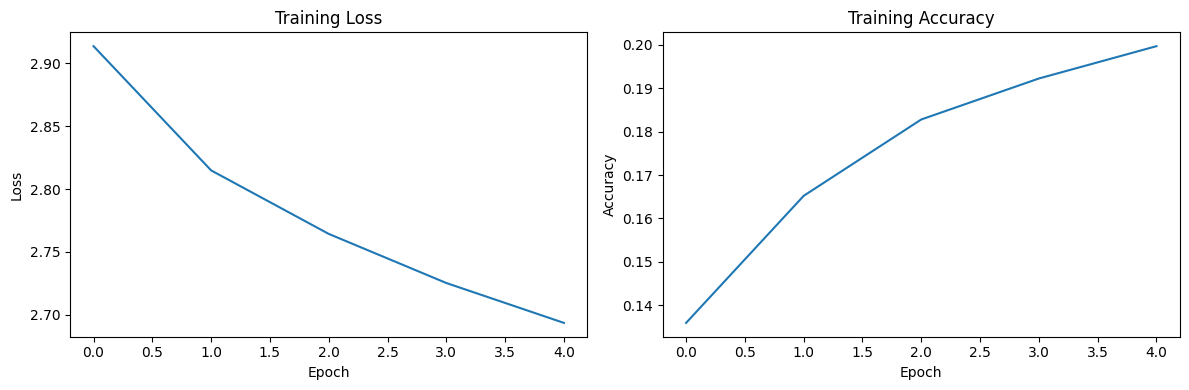

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(train_accuracies)
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')

plt.tight_layout()
plt.savefig('basic_cnn_training.png')
plt.show()